# Predicting House Prices with Linear Regression

## Project Objective

The objective of this project is to build a Linear Regression model to predict house prices based on various housing features. The project demonstrates data preprocessing, exploratory data analysis, feature engineering, model training, evaluation, and business insights generation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Data Collection

In [20]:
df = pd.read_csv("../data/Housing.csv")

In [3]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Data Exploration and Cleaning

In [4]:
df.shape

(545, 13)

In [5]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [7]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [8]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

## Correlation Heatmap

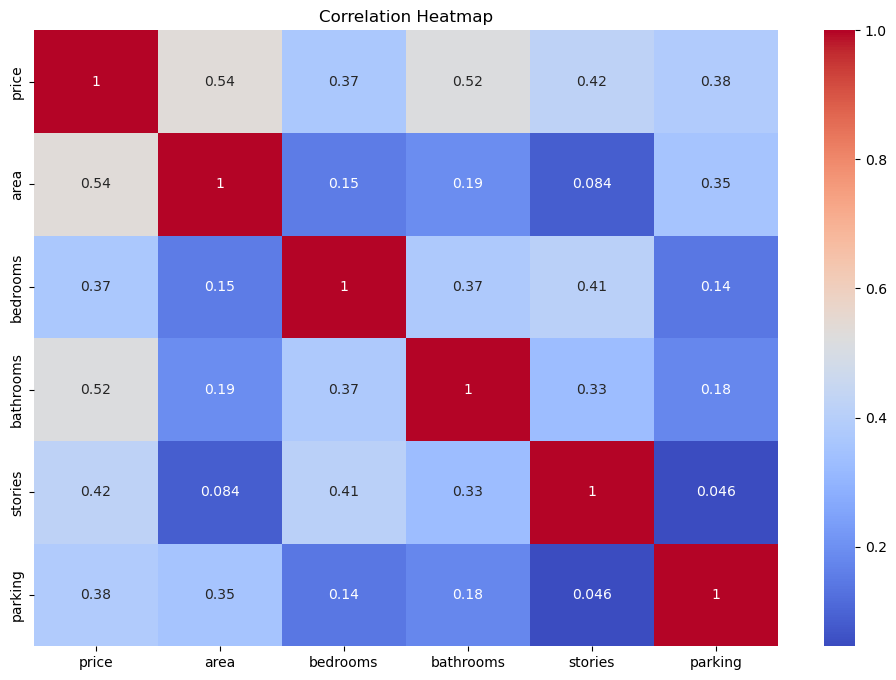

In [9]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

## House Price Distribution

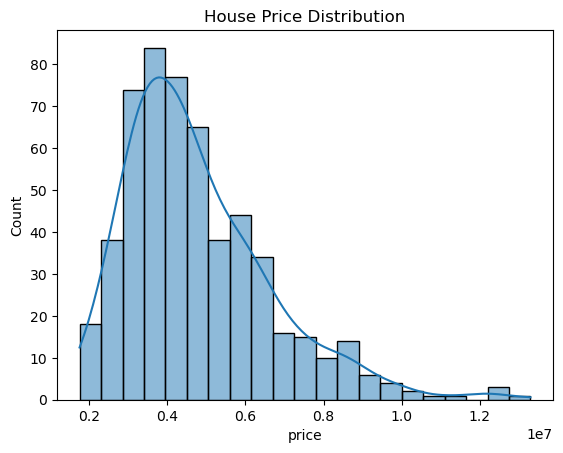

In [10]:
sns.histplot(df['price'], kde=True)

plt.title("House Price Distribution")

plt.show()

## Area vs Price Analysis

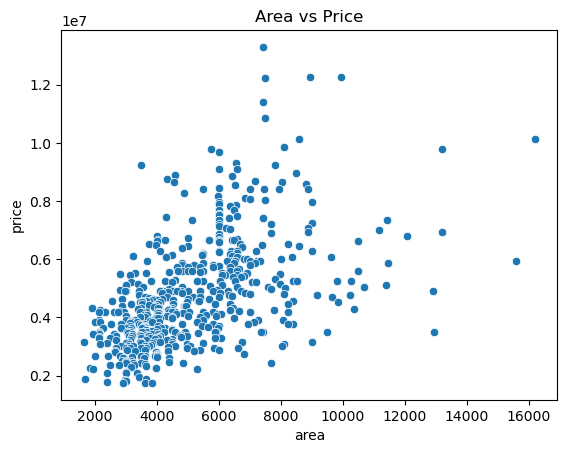

In [11]:
sns.scatterplot(x='area', y='price', data=df)

plt.title("Area vs Price")

plt.show()

## Bedrooms vs Price

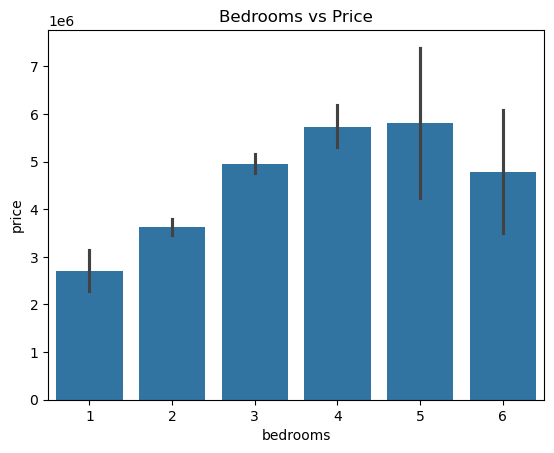

In [12]:
sns.barplot(x='bedrooms', y='price', data=df)

plt.title("Bedrooms vs Price")

plt.show()

## Feature Engineering

In [13]:
df = pd.get_dummies(df, drop_first=True)

## Feature Selection

In [14]:
X = df.drop('price', axis=1)

y = df['price']

## Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Linear Regression Model Training

In [16]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## Predictions

In [17]:
y_pred = model.predict(X_test)

## Model Evaluation

In [18]:
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

print("R2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error: 970043.403920164
Mean Squared Error: 1754318687330.6643
R2 Score: 0.6529242642153184


## Actual vs Predicted Prices

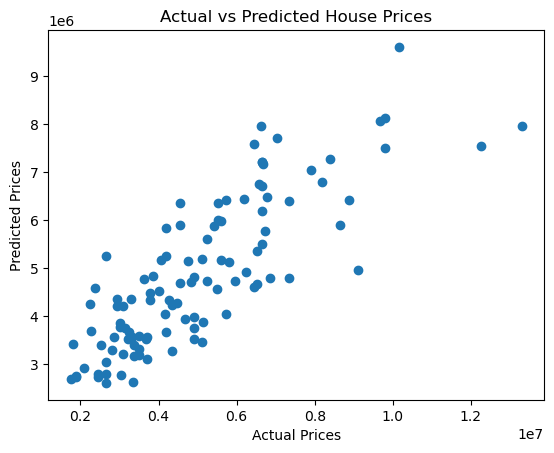

In [19]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

## Business Insights

- House area strongly influences property prices.
- Houses with more bedrooms generally have higher market value.
- Location-related and furnishing features significantly affect pricing.
- Linear Regression successfully identified relationships between housing features and prices.

## Conclusion

This project successfully implemented a Linear Regression model for predicting house prices. The analysis demonstrated how machine learning can help estimate real estate prices using housing features and data-driven insights.